# Modelo de Red Neuronal para predecir los gastos médicos anuales de un grupo de asegurados.

**Objetivo:** Emplear los atributos como: edad, sexo, hábito de fumar, región, número de hijos para predecir los gastos médicos anuales de un asegurado.

In [23]:
# Carga de las dependencia que vamos emplear

# Para manejar el DataFrame u operaciones
import numpy as np
import pandas as pd

# Para gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# Dependencias de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dependencias de Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [24]:
# Identificar el dispositivo con el que estamos trabajando
# MPS (chip de Apple en Mac) -> CUDA (Colab con GPU) -> CPU
device = ('mps' if torch.backends.mps.is_available() else
          'cuda' if torch.cuda.is_available() else 'cpu')
device

'mps'

In [25]:
# Leer los datos: desde Google Drive (Colab) o desde el CSV local (PyCharm)
try:
    from google.colab import drive
    drive.mount('/content/drive/')
    # Ruta y nombre del archivo en Drive
    file = '/content/drive/MyDrive/PYTORCH/datos/insurance.csv'
except ModuleNotFoundError:
    # En local (PyCharm): el CSV está junto al notebook o en la carpeta tarea_1
    import os
    file = 'insurance.csv' if os.path.exists('insurance.csv') else os.path.join('tarea_1', 'insurance.csv')


# FASE I: Lectura y Preparación de los Datos.
Esta fase abarca desde leer los datos hasta convertirlos en un tensor de pytorch y montarlos al device.

In [26]:
 # Leer los datos
 datos=pd.read_csv(file)
 datos.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
# Revisar el conjuntos de datos
print(f'Dimensiones del DataFrame:  {datos.shape[0]} registros y {datos.shape[1]} variables')
print(f'Cantidad de valores nulos:  {int(datos.isna().sum().sum())}')
print(f'Datos duplicados:   {int(datos.duplicated().sum())}')

Dimensiones del DataFrame:  1338 registros y 7 variables
Cantidad de valores nulos:  0
Datos duplicados:   1


In [28]:
# Para mostar los registros duplicados
datos[datos.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [29]:
# Para eliminar los registros duplicados (OPCIONAL)
datos=datos.drop_duplicates()

In [30]:
# Análisis Descriptivo del DataSet
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [31]:
# Selección del Target y de los Atributos
y=datos['charges'].values
X=datos.drop('charges', axis=1)


**NOTA**  
En redes Neuronales, usualmente se divide al conjunto de dato sen tres partes:  
Entrenamiento -> validacion -> Prueba.  

**Entrenamiento:** permite entrenar la red neuronal, es decir identificar los pesos y los sesgos en la red.  

**Validación:** Monitorear el desempeño del modelo entrenado, esto es, verificar que el modelo no se sobreentrene o bien, para hacer la selección del 'mejor' modelo que quizás pueda teener una mejor _métrica de desempeño_ en epocas previas.   

**Prueba:** Calificar el desempeño predictivo del modelo entrenado.



In [32]:
# Dependiendo del tamaño del conjunto de datos
# train (70%), val (15%) y para test (15%)  o
# train (80%), val (10%) y para test (10%)  o
X_train,X_tmp, y_train, y_tmp=train_test_split(X,y,train_size=0.80,random_state=42)
X_val,X_test, y_val, y_test=train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=42)

In [33]:
print(X.shape)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(1337, 6)
(1069, 6)
(134, 6)
(134, 6)
(1069,)
(134,)
(134,)


In [34]:
# Identificación del tipo de dato en cada columna, para dar el preprocesamiento
# adecuado a cada columna
col_num=['age', 'bmi', 'children']
col_cat=['sex','smoker','region']

In [35]:
# Para las variables numéricas -> StandardScaler
# Para las variables categóricas -> OneHotEncoder (descartando una categoría)
col_transform=ColumnTransformer([
    ('num', StandardScaler(), col_num),
    ('cat', OneHotEncoder(drop='first',sparse_output=False), col_cat),
  ])
X_train=col_transform.fit_transform(X_train)
X_val=col_transform.transform(X_val)
X_test=col_transform.transform(X_test)




In [36]:
# Convertir los datos de entrenamiento, validación y prueba a Tensor
# y los subimos al device
X_train=torch.tensor(X_train, dtype=torch.float32, device=device)
X_val=torch.tensor(X_val, dtype=torch.float32, device=device)
X_test=torch.tensor(X_test, dtype=torch.float32, device=device)
y_train=torch.tensor(y_train, dtype=torch.float32, device=device)
y_val=torch.tensor(y_val, dtype=torch.float32, device=device)
y_test=torch.tensor(y_test, dtype=torch.float32, device=device)

# FASE II. Desarrollar la Arquitectura del Modelo

Abarca desde definir la arquitectura del modelo hasta instanciar el modelo y montarlo en el dispositivo adecuado

In [37]:
# ¿Cuántos inputs y cuántos outputs tenemos?
print(f'Inputs: {X_train.shape[1]} atributos')
print(f'Outputs: {y_train.ndim}')

Inputs: 8 atributos
Outputs: 1


**Arquitectura:**   

entrada(8) -> oculta (64) -> oculta (32) -> oculta (16) -> salida(1)



In [38]:
torch.manual_seed(42)
modelo=nn.Sequential(
    nn.Linear(8,64), nn.ReLU(),  # Primer capa oculta
    nn.Linear(64,32), nn.ReLU(), # Segunda capa oculta
    nn.Linear(32,16), nn.ReLU(), # Tercer capa oculta
    nn.Linear(16,1)
).to(device)

# FASE III. Compilar el modelo
Definir al optimizador y la función de pérdida

In [39]:
loss_fn=nn.MSELoss()
optimizer= optim.Adam(modelo.parameters(), lr=0.001)

# FASE IV: Entrenar el modelo

In [40]:
# Número de épocas
n_epochs=5000

# Trazabilidad de la pérdida y la métrica
loss_train=[]
loss_val=[]
metric_train=[]
metric_val=[]

for epochs in range(n_epochs):
  # Poner al modelo en modo train
  modelo.train()
  # Hacemos las predicciones
  y_pred_train=modelo(X_train)
  # Calculamos la pérdida
  loss=loss_fn(y_pred_train,y_train.view(-1,1))
  loss_train.append(loss.detach().cpu().numpy())
  # Calculamos los gradientes de cada parámetros
  loss.backward()
  # Actualizo los valores de los parámetros
  optimizer.step()
  # Evito que los gradientes se acumulen
  optimizer.zero_grad()
  # Métrica de desempeño en el train: MAE ( MSE o r2_score)
  metric=mean_absolute_error(y_pred_train.detach().cpu().numpy(),y_train.detach().cpu().numpy())
  metric_train.append(metric)

  # En el de validación
  with torch.no_grad():
    # Para la pérdida
    y_pred_val=modelo(X_val)
    loss=loss_fn(y_pred_val,y_val.view(-1,1))
    loss_val.append(loss.detach().cpu().numpy())
    # Para la métrica
    metric=mean_absolute_error(y_pred_val.detach().cpu().numpy(),y_val.detach().cpu().numpy())
    metric_val.append(metric)




# FASE V: Mejorar el Desempeño del Modelo

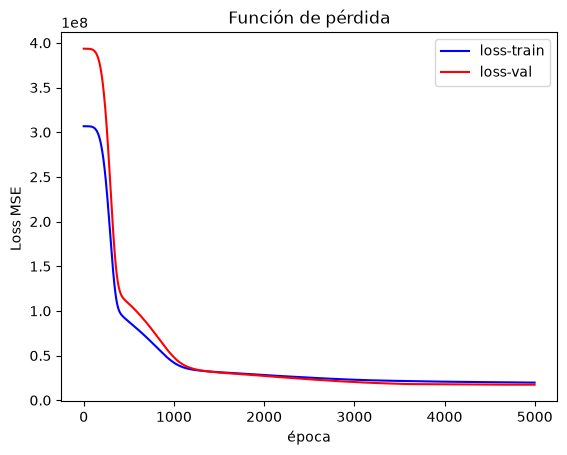

In [41]:
# Monitoreo de la evolución del modelo
plt.plot(range(n_epochs), loss_train, label='loss-train', color='Blue')
plt.plot(range(n_epochs), loss_val, label='loss-val', color='Red')
plt.ylabel('Loss MSE ')
plt.xlabel('época')
plt.title('Función de pérdida')
plt.legend()

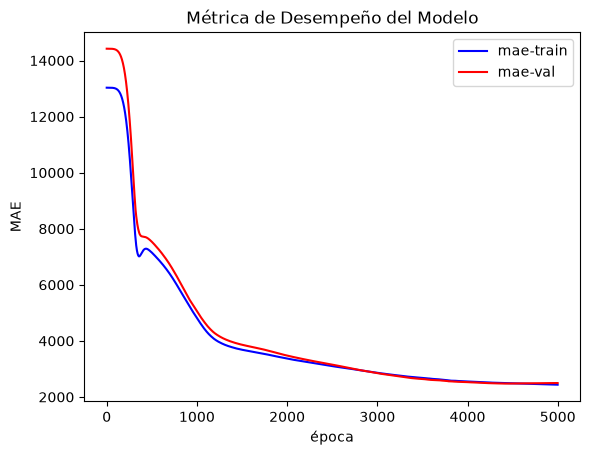

In [42]:
plt.plot(range(n_epochs), metric_train, label='mae-train', color='Blue')
plt.plot(range(n_epochs), metric_val, label='mae-val', color='Red')
plt.ylabel('MAE')
plt.xlabel('época')
plt.title('Métrica de Desempeño del Modelo')
plt.legend()

#### Corregir el sobre-entrenamiento del Modelo.

1. Modificar la arquitectura del modelo. Disminuir el número de neuronas por capa o inclusive el número de capas  

2. Paro anticipado. Detener el entrenamiento del modelo en la época en la cual inicia el sobre-entrenamiento.

3. Intercalar capas de Dropout. Apagar al azar un determinado porcentaje de neuronas en la capa previa. Esto obliga a las neuronas a mejorar sus desempeño

4. Técnicas de regularización.  



## Calificar el desempeño del mejor modelo entrenado.
Esta  evaluación la hacemos en el conjunto de prueba




In [43]:
# Pérdida del modelo en el X_test
with torch.no_grad():
  y_pred=modelo(X_test)
  loss=loss_fn(y_pred,y_test.view(-1,1))
print('Loss:', loss)


Loss: tensor(19147638., device='mps:0')


In [44]:
# Métrica del modelo en el X_test
mean_absolute_error(y_pred.detach().cpu().numpy(),y_test.detach().cpu().numpy())

2411.846923828125

# Tarea No. 1

1.1. Emplear una transformación MinMaxScaler en la variables numéricas.  

1.2. Entrenar el modelo y verrificar que no esté sobreentrenado  

1.3. Comparar la  métrica de desempeño obtenida con la obtenida en la clase con StandardScaler.   

1.4. Si la métrica de desempeño que se emplea es r2_score, qué técnica de escalamiento es mejor: StandardScaler o MinMaxScaler?  

1.5. Si la métrica de desempeño que se emplea es mean_squared_error, qué técnica de escalamiento es mejor: StandardScaler o MinMaxScaler?  


## Resolución Tarea No. 1

Se repite el pipeline de la clase usando `MinMaxScaler` en las variables numéricas (1.1).
Para comparar de forma justa, se entrena el **mismo modelo** (misma arquitectura, semilla,
partición de datos y número de épocas) con `StandardScaler` y con `MinMaxScaler`, y se
evalúan ambos en el mismo conjunto de prueba.

In [45]:
# Función que repite el pipeline de la clase con el escalador que se le indique
from sklearn.preprocessing import MinMaxScaler

def entrenar_evaluar(nombre, escalador):
    # Recargar los datos para no depender del estado de las células anteriores
    file = 'insurance.csv' if os.path.exists('insurance.csv') else os.path.join('tarea_1', 'insurance.csv')
    datos = pd.read_csv(file)
    datos = datos.drop_duplicates()   # misma limpieza que en la clase

    # Target y atributos (igual que la clase)
    y = datos['charges'].values
    X = datos.drop('charges', axis=1)

    # Misma partición: 80% train, 10% val, 10% test
    X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, train_size=0.80, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

    # Preprocesamiento: numéricas -> escalador indicado; categóricas -> OneHotEncoder
    col_num = ['age', 'bmi', 'children']
    col_cat = ['sex', 'smoker', 'region']
    col_transform = ColumnTransformer([
        ('num', escalador, col_num),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), col_cat),
    ])
    X_train = col_transform.fit_transform(X_train)
    X_val = col_transform.transform(X_val)
    X_test = col_transform.transform(X_test)

    # Convertir a Tensor y subir al device (MPS en Mac)
    X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
    X_val   = torch.tensor(X_val,   dtype=torch.float32, device=device)
    X_test  = torch.tensor(X_test,  dtype=torch.float32, device=device)
    y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
    y_val   = torch.tensor(y_val,   dtype=torch.float32, device=device)
    y_test  = torch.tensor(y_test,  dtype=torch.float32, device=device)

    # Misma arquitectura de la clase
    torch.manual_seed(42)
    modelo = nn.Sequential(
        nn.Linear(8, 64), nn.ReLU(),   # Primera capa oculta
        nn.Linear(64, 32), nn.ReLU(),  # Segunda capa oculta
        nn.Linear(32, 16), nn.ReLU(),  # Tercera capa oculta
        nn.Linear(16, 1)
    ).to(device)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)

    n_epochs = 5000
    loss_train, loss_val = [], []
    metric_train, metric_val = [], []

    for epochs in range(n_epochs):
        modelo.train()
        y_pred_train = modelo(X_train)
        loss = loss_fn(y_pred_train, y_train.view(-1, 1))
        loss_train.append(loss.detach().cpu().numpy())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        metric = mean_absolute_error(y_pred_train.detach().cpu().numpy(), y_train.detach().cpu().numpy())
        metric_train.append(metric)

        with torch.no_grad():
            y_pred_val = modelo(X_val)
            loss = loss_fn(y_pred_val, y_val.view(-1, 1))
            loss_val.append(loss.detach().cpu().numpy())
            metric = mean_absolute_error(y_pred_val.detach().cpu().numpy(), y_val.detach().cpu().numpy())
            metric_val.append(metric)

    # Evaluación en el conjunto de prueba
    with torch.no_grad():
        y_pred_test = modelo(X_test)
        loss_test = loss_fn(y_pred_test, y_test.view(-1, 1)).item()
    y_pred_test = y_pred_test.detach().cpu().numpy().ravel()
    y_test_np = y_test.detach().cpu().numpy().ravel()

    return {
        'nombre': nombre,
        'loss_train': loss_train, 'loss_val': loss_val,
        'metric_train': metric_train, 'metric_val': metric_val,
        'test_loss_mse': loss_test,
        'test_mae': mean_absolute_error(y_test_np, y_pred_test),
        'test_mse': mean_squared_error(y_test_np, y_pred_test),
        'test_r2': r2_score(y_test_np, y_pred_test),
    }

In [46]:
# 1.1 y 1.2 — Pipeline con MinMaxScaler y entrenamiento del modelo
res_minmax = entrenar_evaluar('MinMaxScaler', MinMaxScaler())
print(f"Pérdida (MSE) en test: {res_minmax['test_loss_mse']:,.2f}")
print(f"MAE en test:            {res_minmax['test_mae']:,.2f}")

Pérdida (MSE) en test: 21,507,368.00
MAE en test:            2,786.95


In [47]:
# Referencia de la clase: pipeline con StandardScaler (mismos datos, semilla y épocas)
res_std = entrenar_evaluar('StandardScaler', StandardScaler())
print(f"Pérdida (MSE) en test: {res_std['test_loss_mse']:,.2f}")
print(f"MAE en test:            {res_std['test_mae']:,.2f}")

Pérdida (MSE) en test: 19,147,638.00
MAE en test:            2,411.85


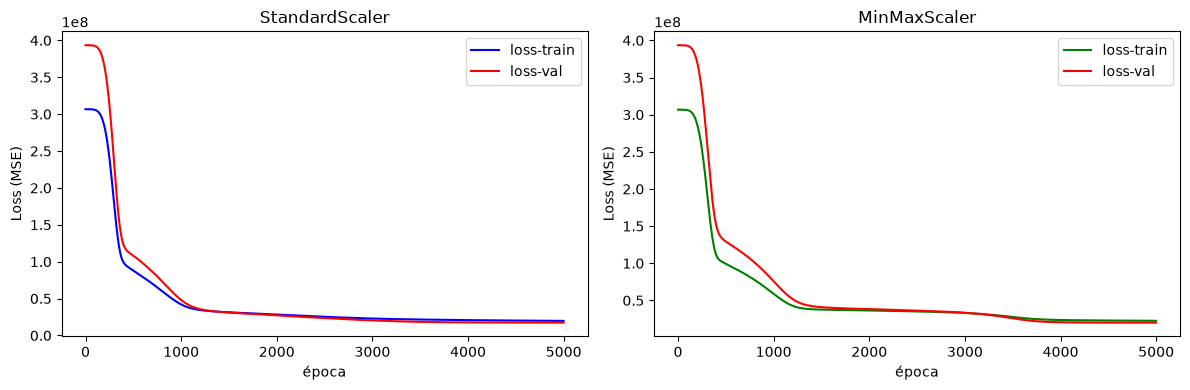

StandardScaler: loss train final = 19,741,874.00 | loss val final = 17,387,994.00
MinMaxScaler:   loss train final = 22,543,400.00 | loss val final = 20,092,088.00


In [48]:
# 1.2 — Verificar que el modelo no esté sobreentrenado: pérdida train vs validación
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for res, ax, color in [(res_std, ejes[0], 'Blue'), (res_minmax, ejes[1], 'Green')]:
    ax.plot(range(len(res['loss_train'])), res['loss_train'], label='loss-train', color=color)
    ax.plot(range(len(res['loss_val'])), res['loss_val'], label='loss-val', color='Red')
    ax.set_xlabel('época')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(res['nombre'])
    ax.legend()
plt.tight_layout()
plt.show()

print(f"StandardScaler: loss train final = {float(res_std['loss_train'][-1]):,.2f} | loss val final = {float(res_std['loss_val'][-1]):,.2f}")
print(f"MinMaxScaler:   loss train final = {float(res_minmax['loss_train'][-1]):,.2f} | loss val final = {float(res_minmax['loss_val'][-1]):,.2f}")

In [49]:
# 1.3 — Comparación de las métricas de desempeño en el conjunto de prueba
comparacion = pd.DataFrame({
    'MSE (test)': [res_std['test_mse'], res_minmax['test_mse']],
    'MAE (test)': [res_std['test_mae'], res_minmax['test_mae']],
    'r2_score (test)': [res_std['test_r2'], res_minmax['test_r2']],
}, index=['StandardScaler (clase)', 'MinMaxScaler (tarea)'])
comparacion.round(2)

,MSE (test),MAE (test),r2_score (test)
StandardScaler (clase),19147638.0,2411.85,0.89
MinMaxScaler (tarea),21507366.0,2786.95,0.88


### 1.4 y 1.5 — ¿Qué técnica de escalamiento es mejor?

Resultados obtenidos en el conjunto de prueba (ver la tabla anterior):

- **1.4 Con r2_score:** gana **StandardScaler** (0.895 frente a 0.882 de MinMaxScaler).
- **1.5 Con mean_squared_error:** gana **StandardScaler** (19,147,638 frente a 21,507,368 de MinMaxScaler; menor es mejor).

**Razonamiento:** en teoría, cambiar la escala de las variables no agrega ni quita
información, por lo que ambos escaladores deberían dar resultados muy parecidos. Las
pequeñas diferencias observadas se deben a la dinámica de optimización de la red: en este
caso el modelo convergió ligeramente mejor con `StandardScaler` (menor MAE y MSE, y mayor
r2_score). Además, en ambos casos el modelo **no está sobreentrenado**, porque la pérdida
de validación queda muy cerca de la de entrenamiento.